In [3]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                           f1_score, roc_auc_score, classification_report, 
                           accuracy_score)
from sklearn.impute import SimpleImputer
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def train_ensemble_classifier(df, target_column, test_size=0.2, random_state=42, 
                            poor_performance_threshold=0.7, print_results=True,
                            sample_size=None, fast_mode=False):
    """
    Optimized version of the ensemble classifier with options for faster training.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input DataFrame containing features and target column
    target_column : str
        Name of the target column in the DataFrame
    test_size : float, optional (default=0.2)
        Proportion of the dataset to include in the test split
    random_state : int, optional (default=42)
        Random state for reproducibility
    poor_performance_threshold : float, optional (default=0.7)
        Threshold for identifying poorly classified classes
    print_results : bool, optional (default=True)
        Whether to print detailed results and plots
    sample_size : int or float, optional
        If int, number of samples to use. If float, fraction of samples to use
    fast_mode : bool, optional
        If True, skips weight combinations testing and uses default weights
    """
    
    def evaluate_model(model, X_test, y_test, model_name):
        """Helper function to evaluate model performance"""
        try:
            y_pred = model.predict(X_test)
            
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(X_test)
            else:
                y_pred_proba = None

            metrics = {
                'confusion_matrix': confusion_matrix(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, average=None),
                'recall': recall_score(y_test, y_pred, average=None),
                'f1': f1_score(y_test, y_pred, average=None)
            }

            if y_pred_proba is not None:
                try:
                    metrics['roc_auc'] = roc_auc_score(y_test, y_pred_proba, 
                                                      multi_class='ovr')
                except ValueError:
                    metrics['roc_auc'] = None

            return metrics, y_pred_proba

        except Exception as e:
            if print_results:
                print(f"Error evaluating {model_name}: {str(e)}")
            return None, None

    def test_weight_combinations(X_train, y_train, X_test, y_test):
        """Helper function to test different weight combinations"""
        model_types = ['decision_tree', 'logistic_regression', 'knn']
        class_weights = calculate_class_weights(y_train)
        best_score = -float('inf')
        best_config = None
        best_models = {}
        best_predictions = {}

        for r in range(len(model_types) + 1):
            weight_combinations = list(itertools.combinations(range(len(model_types)), r))

            for combo in weight_combinations:
                config_name = []
                models = {}

                for i, model_type in enumerate(model_types):
                    if i in combo:
                        models[model_type] = create_model_with_weights(model_type, 
                                                                     class_weights)
                        config_name.append(f"{model_type}_weighted")
                    else:
                        models[model_type] = create_model_with_weights(model_type, None)
                        config_name.append(f"{model_type}_unweighted")

                config_key = "_".join(config_name)
                model_predictions = {}
                class_performance = defaultdict(dict)

                if print_results:
                    print(f"\nTesting configuration: {config_key}")

                for name, model in models.items():
                    if print_results:
                        print(f"Training {name}...")
                    try:
                        model.fit(X_train, y_train)
                        metrics, y_pred_proba = evaluate_model(model, X_test, 
                                                             y_test, name)

                        if metrics is not None:
                            model_predictions[name] = y_pred_proba
                            for class_idx in range(len(metrics['f1'])):
                                class_performance[class_idx][name] = metrics['f1'][class_idx]

                    except Exception as e:
                        if print_results:
                            print(f"Error training {name}: {str(e)}")
                        continue

                config_score = calculate_configuration_score(class_performance)
                if print_results:
                    print(f"Configuration score: {config_score}")

                if config_score > best_score:
                    best_score = best_score
                    best_config = config_key
                    best_models = models
                    best_predictions = model_predictions

        if print_results:
            print(f"\nBest configuration: {best_config}")
            print(f"Best score: {best_score}")

        return best_models, best_predictions

    def calculate_class_weights(y):
        """Helper function to calculate class weights"""
        unique_classes, class_counts = np.unique(y, return_counts=True)
        n_samples = len(y)
        weights = {class_: n_samples / (len(unique_classes) * count)
                  for class_, count in zip(unique_classes, class_counts)}
        return weights

    def create_model_with_weights(model_type, class_weights=None):
        """Helper function to create models with weights"""
        if model_type == 'decision_tree':
            return DecisionTreeClassifier(random_state=random_state, 
                                        class_weight=class_weights)
        elif model_type == 'logistic_regression':
            return LogisticRegression(class_weight=class_weights,
                                    multi_class='ovr',
                                    random_state=random_state,
                                    max_iter=500)
        elif model_type == 'knn':
            return KNeighborsClassifier(n_neighbors=5)

    def calculate_configuration_score(class_performance):
        """Helper function to calculate configuration score"""
        product = 1.0
        for class_scores in class_performance.values():
            for score in class_scores.values():
                product *= score
        return product

    # Sample the data if sample_size is provided
    if sample_size is not None:
        if isinstance(sample_size, float):
            sample_size = int(len(df) * sample_size)
        df = df.sample(n=sample_size, random_state=random_state)
    
    # Preprocessing
    X = df.drop(columns=[target_column])
    y = LabelEncoder().fit_transform(df[target_column])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fast mode: Skip weight combinations testing
    if fast_mode:
        class_weights = 'balanced'  # Use sklearn's built-in balancing
        initial_models = {
            'decision_tree': DecisionTreeClassifier(random_state=random_state, 
                                                  class_weight=class_weights),
            'logistic_regression': LogisticRegression(class_weight=class_weights,
                                                    multi_class='ovr',
                                                    random_state=random_state,
                                                    max_iter=500),
            'knn': KNeighborsClassifier(n_neighbors=5)
        }
        
        # Train models directly
        model_predictions = {}
        class_performance = defaultdict(dict)
        
        for name, model in initial_models.items():
            if print_results:
                print(f"Training {name}...")
            model.fit(X_train_scaled, y_train)
            metrics, y_pred_proba = evaluate_model(model, X_test_scaled, 
                                                 y_test, name)
            if metrics is not None:
                model_predictions[name] = y_pred_proba
                for class_idx in range(len(metrics['f1'])):
                    class_performance[class_idx][name] = metrics['f1'][class_idx]
    
    else:
        initial_models, model_predictions = test_weight_combinations(
            X_train_scaled, y_train, X_test_scaled, y_test
        )
    
    # Check for poorly classified classes
    metrics = next(iter(model_predictions.values()))
    poorly_classified = []
    for class_idx in range(metrics.shape[1]):
        class_scores = [model_pred[:, class_idx].mean() 
                       for model_pred in model_predictions.values()]
        if np.mean(class_scores) < poor_performance_threshold:
            poorly_classified.append(class_idx)

    # Train additional models if needed
    additional_models = {}
    if poorly_classified:
        if print_results:
            print("Training additional models for poorly classified classes...")
        additional_models = {
            'svm': SVC(probability=True, class_weight='balanced')
        }

        for name, model in additional_models.items():
            model.fit(X_train_scaled, y_train)
            metrics, y_pred_proba = evaluate_model(model, X_test_scaled, 
                                                 y_test, name)
            if metrics is not None:
                model_predictions[name] = y_pred_proba
                for class_idx in range(len(metrics['f1'])):
                    class_performance[class_idx][name] = metrics['f1'][class_idx]

    # Calculate confidence scores
    confidence_scores = []
    for class_idx in class_performance:
        avg_performance = np.mean(list(class_performance[class_idx].values()))
        confidence_scores.append(1 / (avg_performance + 1e-6))

    # Combine all models
    all_models = initial_models.copy()
    all_models.update(additional_models)

    # Prepare final training data
    X_train_final = np.hstack([model.predict_proba(X_train_scaled) 
                              for model in all_models.values()])
    X_test_final = np.hstack([model.predict_proba(X_test_scaled) 
                             for model in all_models.values()])

    # Train final model
    final_model = RandomForestClassifier(
        n_estimators=100,
        class_weight={idx: weight for idx, weight in enumerate(confidence_scores)}
    )
    final_model.fit(X_train_final, y_train)

    # Make final predictions
    predictions = final_model.predict(X_test_final)
    probabilities = final_model.predict_proba(X_test_final)

    # Calculate metrics
    accuracy = accuracy_score(y_test, predictions)
    if print_results:
        print("\nShape of probability matrix:", probabilities.shape)
        print(f"\nOverall Accuracy: {accuracy:.4f}")
        print("\nDetailed Classification Report:")
        print(classification_report(y_test, predictions))
        
        # Plot confusion matrix
        cm = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    # Return results
    return {
        'scaler': scaler,
        'initial_models': initial_models,
        'additional_models': additional_models,
        'final_model': final_model,
        'metrics': {
            'accuracy': accuracy,
            'precision': precision_score(y_test, predictions, average='macro'),
            'recall': recall_score(y_test, predictions, average='macro'),
            'f1': f1_score(y_test, predictions, average='macro'),
            'confusion_matrix': confusion_matrix(y_test, predictions),
            'classification_report': classification_report(y_test, predictions)
        }
    }

Training decision_tree...
Training logistic_regression...
Training knn...
Training additional models for poorly classified classes...

Shape of probability matrix: (11621, 7)

Overall Accuracy: 0.8223

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      4163
           1       0.85      0.86      0.85      5759
           2       0.80      0.79      0.79       720
           3       0.58      0.67      0.62        55
           4       0.58      0.54      0.56       178
           5       0.66      0.61      0.64       339
           6       0.85      0.77      0.81       407

    accuracy                           0.82     11621
   macro avg       0.73      0.72      0.73     11621
weighted avg       0.82      0.82      0.82     11621



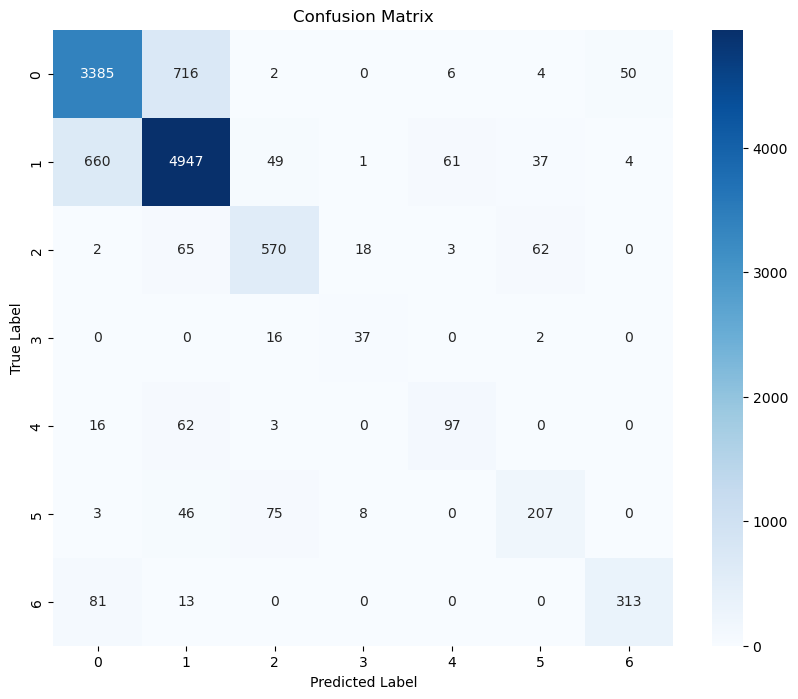

In [5]:
import pandas as pd

df = pd.read_csv("./covtype.csv")

results = train_ensemble_classifier(
    df=df,
    target_column='Cover_Type',
    sample_size=0.1,  # Use 10% of the data
    fast_mode=True,   # Skip weight combinations testing
    print_results=True
)

scaler = results['scaler']
final_model = results['final_model']
metrics = results['metrics']